In [ ]:
# Evaluación del modelo GloVe + MLP

## 1. Imports y configuración
%pip install torch pandas numpy scikit-learn matplotlib seaborn

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
import seaborn as sns  # opcional para matríz más vistosa

# Ajustar paths
DATA_PATH = "../data/preprocessed_tweets.csv"
MODEL_PATH = "../outputs/embeddings_models/mlp_model.pt"  
GLOVE_PATH = "../data/glove.6B.100d.txt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 64

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Repite aquí la clase TweetDataset
class TweetDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = self.texts.iloc[idx]
        idxs = [self.word2idx.get(tok, self.word2idx['<unk>']) for tok in tokens]
        if len(idxs) < self.max_len:
            idxs += [self.word2idx['<pad>']] * (self.max_len - len(idxs))
        else:
            idxs = idxs[:self.max_len]
        return torch.tensor(idxs), torch.tensor(self.labels[idx], dtype=torch.long)

In [9]:
# 3.1 Carga del DataFrame
df = pd.read_csv(DATA_PATH)
# Asegura que no haya floats en tokens
df['tokens'] = df['tokens'].fillna('').astype(str)

# 3.2 Split estratificado con los mismos parámetros que en train
from sklearn.model_selection import train_test_split

# Ahora sí puedes hacer el split sin problemas
texts = df['tokens'].apply(lambda x: x.split())
labels = df['label'].values
texts_train, texts_val, labels_train, labels_val = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
# 3.3 Diccionario de vocabulario (debes recargar o salvarlo)
# Aquí asumimos que guardaste word2idx en train; si no, vuelve a generarlo:
word2idx = {'<pad>':0,'<unk>':1}
with open(GLOVE_PATH,'r',encoding='utf-8') as f:
    for line in f:
        w, *vec = line.strip().split()
        if w not in word2idx:
            word2idx[w] = len(word2idx)

# 3.4 Validación DataLoader
val_ds = TweetDataset(texts_val.reset_index(drop=True), labels_val, word2idx)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [10]:
# Define la clase de tu MLP (igual que en train_glove_mlp.py)
class MLPClassifier(torch.nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=64, output_dim=2):
        # hidden_dim=64 y dropout=0.3 para que coincidan con HIDDEN_DIM/DROPOUT_PROB
        # usados de verdad en train_glove_neural.py; si no, load_state_dict() falla
        # por incompatibilidad de tamaños entre las capas.
        super().__init__()
        _, emb_dim = embedding_matrix.size()
        self.embedding = torch.nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.fc1 = torch.nn.Linear(emb_dim * MAX_LEN, hidden_dim)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.3)
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        emb = self.embedding(x)
        flat = emb.view(x.size(0), -1)
        hid = self.relu(self.fc1(flat))
        hid = self.dropout(hid)
        return self.fc2(hid)

# Carga de embeddings
emb_list = [np.zeros(100), np.random.normal(scale=0.6, size=(100,))]
with open(GLOVE_PATH,'r',encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word, vec = parts[0], np.array(parts[1:],dtype=np.float32)
        emb_list.append(vec)
embedding_matrix = torch.tensor(np.stack(emb_list)).float()

# Instanciar y cargar pesos
model = MLPClassifier(embedding_matrix).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

MLPClassifier(
  (embedding): Embedding(400003, 100)
  (fc1): Linear(in_features=5000, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [14]:
all_preds = []
all_probs = []
with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(DEVICE)
        out = model(xb)
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = (probs > 0.3).astype(int)  # umbral 0.5, pruébalo también 0.4 o 0.6
        all_probs.extend(probs)
        all_preds.extend(preds)

# Classification report
print(classification_report(labels_val, all_preds, digits=4))

# Confusion matrix
cm = confusion_matrix(labels_val, all_preds)
print("Confusion matrix:\n", cm)

              precision    recall  f1-score   support

           0     0.8859    0.3296    0.4805     12034
           1     0.3166    0.8797    0.4656      4248

    accuracy                         0.4732     16282
   macro avg     0.6012    0.6047    0.4731     16282
weighted avg     0.7374    0.4732    0.4766     16282

Confusion matrix:
 [[3967 8067]
 [ 511 3737]]


In [ ]:
# 7. Ajuste de umbral: prueba varios thresholds para la clase positiva (sarcasmo)
import numpy as np
from sklearn.metrics import classification_report

print("Threshold | Prec_1 | Rec_1 | F1_1")
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_t = (np.array(all_probs) > thr).astype(int)
    rpt = classification_report(labels_val, preds_t, output_dict=True)
    prec1 = rpt['1']['precision']
    rec1  = rpt['1']['recall']
    f11   = rpt['1']['f1-score']
    print(f"   {thr:.1f}    |  {prec1:.3f}  | {rec1:.3f} | {f11:.3f}")

#se ve que el umbral 0.3 es el que consigue maximizar los resultados, así que será el elegido

Threshold | Prec_1 | Rec_1 | F1_1
   0.3    |  0.317  | 0.880 | 0.466
   0.4    |  0.314  | 0.813 | 0.453
   0.5    |  0.307  | 0.691 | 0.425
   0.6    |  0.244  | 0.212 | 0.227
   0.7    |  0.131  | 0.018 | 0.032


In [ ]:
import itertools, time
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd

# 1) Subsample del train para tuning rápido (20 %)
n_sub = int(0.2 * len(texts_train))
idx_sub = np.random.choice(len(texts_train), size=n_sub, replace=False)
texts_sub = texts_train.iloc[idx_sub].reset_index(drop=True)
labels_sub = labels_train[idx_sub]

# 2) Recalcular pesos de clase sobre el subset
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_sub),
    y=labels_sub
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

# 3) Parámetros fijos y grid
LR, BATCH_SIZE, EPOCHS = 1e-3, 64, 1
max_lens = [50, 100]
hiddens  = [64, 128]
dropouts = [0.3, 0.5]

results = []

for max_len, hid_dim, dp in itertools.product(max_lens, hiddens, dropouts):
    start = time.time()

    # DataLoaders con nuevo max_len
    train_ds = TweetDataset(texts_sub, labels_sub, word2idx, max_len=max_len)
    val_ds   = TweetDataset(texts_val.reset_index(drop=True), labels_val, word2idx, max_len=max_len)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Modelo MLPv2 dinámico
    class MLPv2(nn.Module):
        def __init__(self, emb_mat):
            super().__init__()
            _, emb_dim = emb_mat.size()
            self.embedding = nn.Embedding.from_pretrained(emb_mat, freeze=True)
            self.fc1       = nn.Linear(emb_dim * max_len, hid_dim)
            self.relu      = nn.ReLU()
            self.dropout   = nn.Dropout(dp)
            self.fc2       = nn.Linear(hid_dim, 2)

        def forward(self, x):
            emb  = self.embedding(x)
            flat = emb.view(x.size(0), -1)
            hid  = self.relu(self.fc1(flat))
            hid  = self.dropout(hid)
            return self.fc2(hid)

    model_t   = MLPv2(embedding_matrix).to(DEVICE)
    optimizer = torch.optim.Adam(model_t.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # 1 epoch de entrenamiento
    model_t.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_t(xb), yb)
        loss.backward()
        optimizer.step()

    # Evaluación en validación (umbral 0.3)
    model_t.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out   = model_t(xb)
            probs = torch.softmax(out, dim=1)[:,1].cpu().numpy()
            preds = (probs > 0.3).astype(int)
            all_p.extend(preds)
            all_l.extend(yb.cpu().numpy())

    prec, rec, f1, _ = precision_recall_fscore_support(all_l, all_p, average='binary')
    elapsed = time.time() - start

    results.append({
        'max_len':   max_len,
        'hidden_dim':hid_dim,
        'dropout':   dp,
        'F1_val':    f1,
        'Prec1':     prec,
        'Rec1':      rec,
        'time_s':    elapsed
    })

# 4) Mostrar los 5 mejores resultados
df_res = pd.DataFrame(results).sort_values('F1_val', ascending=False)
df_res.head(5)


,max_len,hidden_dim,dropout,F1_val,Prec1,Rec1,time_s
0,50,64,0.3,0.451822,0.294729,0.967514,3.598275
4,100,64,0.3,0.446839,0.288887,0.985876,7.485035
2,50,128,0.3,0.446026,0.287967,0.988701,7.972153
6,100,128,0.3,0.445599,0.287532,0.989642,9.617523
1,50,64,0.5,0.443118,0.285685,0.987053,4.208091


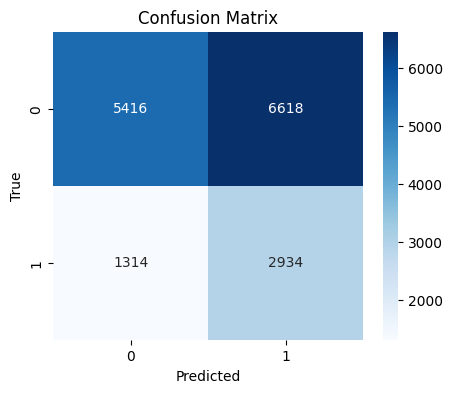

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()